<a href="https://colab.research.google.com/github/meetpatel120508-ctrl/plutoacadamypro2/blob/main/Project02_ML_HeartDisease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 02 — Machine Learning Model: Predict & Evaluate
### Heart Disease Prediction (Classification)

**Pluto Academy AI & ML Internship Program 2026**

**Dataset:** [Heart Disease Dataset — Kaggle (johnsmith88)](https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset)

**Role:** ML Engineer at a tech company, tasked with building, training, and evaluating a model that predicts whether a patient has heart disease, comparing 3 different algorithms.

---
**Note on data loading:** This notebook is written to run in Google Colab. If running there, uncomment and run the Kaggle download cell below (Step 0) to fetch the real dataset. A locally bundled `heart.csv` is also provided for offline reproducibility — both have the same column schema (`age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal, target`).


## Step 0 — Setup & Load Data

In [2]:
# --- Option A: Download from Kaggle (run in Colab) ---
# !pip install kaggle -q
# from google.colab import files
# files.upload()  # upload your kaggle.json API token
# !mkdir -p ~/.kaggle && mv kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
# !kaggle datasets download -d johnsmith88/heart-disease-dataset
# !unzip -o heart-disease-dataset.zip

# --- Option B: Load local CSV (already provided in this repo) ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay,
                              classification_report)

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

df = pd.read_csv("heart.csv")
print("Shape:", df.shape)
df.head()

Shape: (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,67,1,0,104.0,449.0,0,2,91.0,0,1.6,0,4,0,0
1,57,1,1,143.0,286.0,0,0,124.0,0,1.2,2,4,3,0
2,43,0,2,124.0,252.0,0,1,173.0,0,0.8,1,2,0,1
3,71,1,2,149.0,545.0,0,1,129.0,0,1.2,2,4,1,1
4,36,0,3,172.0,207.0,0,0,142.0,0,0.5,0,3,0,0


## Step 1 — Load, Explore & Preprocess

### 1a. Basic Inspection


In [3]:
print("Data types:\n")
print(df.dtypes)
print("\nMissing values:\n")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nTarget distribution:\n", df['target'].value_counts())
df.describe()

Data types:

age           int64
sex           int64
cp            int64
trestbps    float64
chol        float64
fbs           int64
restecg       int64
thalach     float64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

Missing values:

age         0
sex         0
cp          0
trestbps    8
chol        8
fbs         0
restecg     0
thalach     8
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Duplicate rows: 0

Target distribution:
 target
0    513
1    512
Name: count, dtype: int64


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1017.000000,1017.000000,1025.000000,1025.000000,1017.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000
mean,53.272195,0.478049,1.479024,146.070796,343.619469,0.132683,1.038049,137.540806,0.324878,0.957366,1.01561,2.125854,1.506341,0.499512
std,14.150249,0.499762,1.117946,31.130170,128.348703,0.339397,0.818199,37.950296,0.468558,0.950682,0.82783,1.433679,1.122484,0.500244
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,41.000000,0.000000,1.000000,118.000000,233.000000,0.000000,0.000000,106.000000,0.000000,0.300000,0.00000,1.000000,1.000000,0.000000
50%,54.000000,0.000000,1.000000,145.000000,339.000000,0.000000,1.000000,139.000000,0.000000,0.700000,1.00000,2.000000,1.000000,0.000000
75%,65.000000,1.000000,2.000000,175.000000,456.000000,0.000000,2.000000,169.000000,1.000000,1.300000,2.00000,3.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.00000,4.000000,3.000000,1.000000


### Dataset Summary

- The dataset contains **1,025 patient records** with **14 columns**: 13 clinical features (age, sex, chest pain type `cp`, resting blood pressure `trestbps`, cholesterol `chol`, fasting blood sugar `fbs`, resting ECG `restecg`, max heart rate `thalach`, exercise-induced angina `exang`, ST depression `oldpeak`, slope, number of major vessels `ca`, thalassemia `thal`) and 1 binary `target` column (1 = heart disease present, 0 = absent).
- A small number of missing values (8 each) exist in `trestbps`, `chol`, and `thalach` — these are continuous physiological measurements.
- The target classes are nearly balanced (≈50/50), which is good for classification — no severe class imbalance correction needed.
- All columns are numeric already (categorical clinical codes like `cp`, `restecg`, `slope`, `thal` are encoded as integers in the source data).
- No duplicate rows were found.

### 1b. Handle Missing Values

**Decision:** For `trestbps`, `chol`, and `thalach`, we impute missing values with the **median** of each column. Median is preferred over mean here because these clinical measurements can have outliers (e.g. very high cholesterol readings), and median is more robust to skew. Dropping rows was avoided since missingness is minimal (~0.8% per column) but every row of patient data is valuable for model training.


In [4]:
for col in ['trestbps', 'chol', 'thalach']:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f"Filled {col} missing values with median = {median_val}")

print("\nRemaining missing values:\n", df.isnull().sum().sum())

Filled trestbps missing values with median = 145.0
Filled chol missing values with median = 339.0
Filled thalach missing values with median = 139.0

Remaining missing values:
 0


### 1c. Encode Categorical Variables

**Decision:** All categorical clinical features (`sex`, `cp`, `fbs`, `restecg`, `exang`, `slope`, `ca`, `thal`) are **already integer-encoded** in this dataset (this is standard for the UCI Heart Disease dataset). No further one-hot encoding is required because:
- `sex`, `fbs`, `exang` are binary (0/1) — no encoding needed.
- `cp`, `restecg`, `slope`, `thal`, `ca` are ordinal/categorical integer codes with a small number of categories — tree-based and distance-based models can handle these directly, and one-hot encoding them would add many sparse columns with limited benefit for this dataset size.

We will, however, **scale numeric features** (`age`, `trestbps`, `chol`, `thalach`, `oldpeak`) since KNN and Logistic Regression are sensitive to feature scale.


In [5]:
# Separate features and target
X = df.drop('target', axis=1)
y = df['target']

print("Feature columns:", list(X.columns))
print("Target distribution:\n", y.value_counts(normalize=True))

Feature columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
Target distribution:
 target
0    0.500488
1    0.499512
Name: proportion, dtype: float64


### 1d. Train/Test Split (80/20)

**Decision:** We use an 80/20 stratified split so both train and test sets preserve the original ~50/50 class balance. Stratification is important for classification tasks to ensure the test set is representative.


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTrain target balance:\n", y_train.value_counts(normalize=True))
print("\nTest target balance:\n", y_test.value_counts(normalize=True))

Train shape: (820, 13)
Test shape: (205, 13)

Train target balance:
 target
0    0.5
1    0.5
Name: proportion, dtype: float64

Test target balance:
 target
0    0.502439
1    0.497561
Name: proportion, dtype: float64


### 1e. Feature Scaling

**Decision:** Apply `StandardScaler` (fit on train, applied to both train and test) so that Logistic Regression and KNN — which are sensitive to feature magnitude — are not dominated by large-range features like `chol` (cholesterol, ranges to 500+) over small-range features like `oldpeak` (0-6.2). Random Forest is scale-invariant but scaling does no harm to it, so we use the same scaled data for all 3 models for a fair, consistent comparison.


In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete. Sample scaled row:\n", X_train_scaled[0])

Scaling complete. Sample scaled row:
 [-1.65145982 -0.96877979  1.344779    0.528382   -1.22248651 -0.40388187
 -0.03881531  1.08049228  1.44718334 -0.90603539  1.17712033 -0.79851855
 -1.35291326]


## Step 2 — Feature Engineering

### 2a. Correlation Analysis


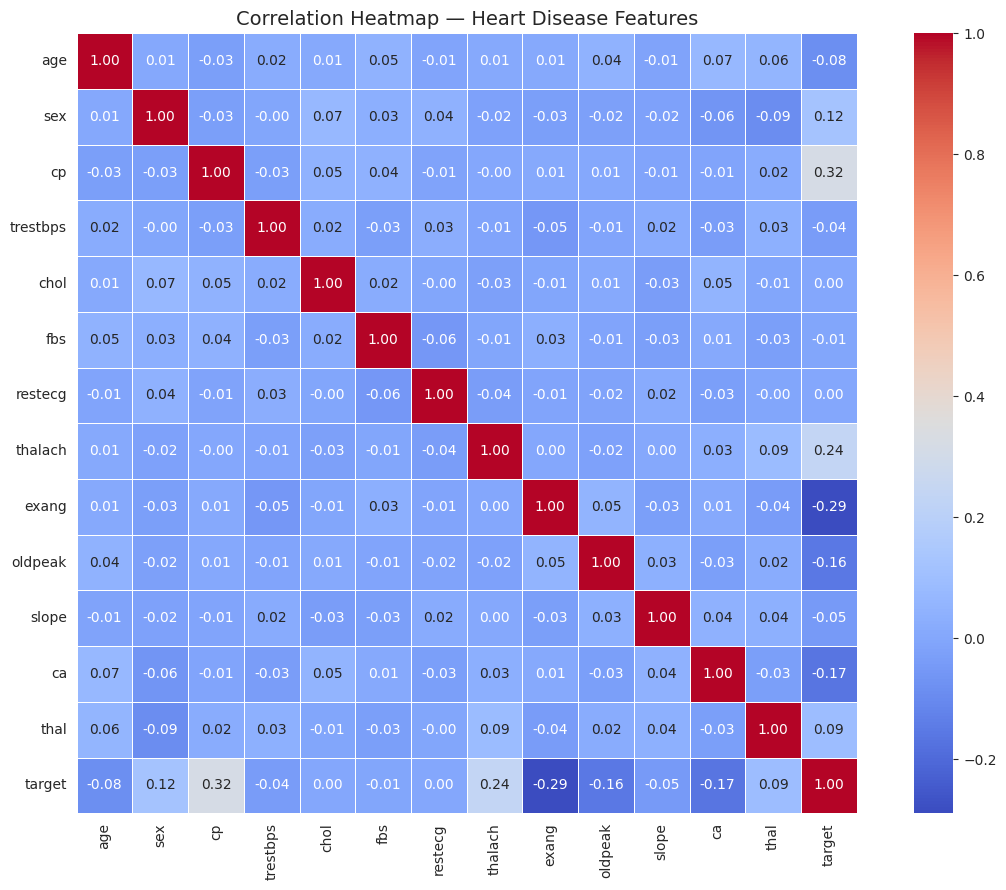

Correlation with target (sorted):

target      1.000000
cp          0.315610
thalach     0.236793
sex         0.122026
thal        0.090007
chol        0.001257
restecg     0.001238
fbs        -0.005370
trestbps   -0.041612
slope      -0.047145
age        -0.083930
oldpeak    -0.156003
ca         -0.165355
exang      -0.288884
Name: target, dtype: float64


In [8]:
plt.figure(figsize=(12, 9))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True, linewidths=0.5)
plt.title("Correlation Heatmap — Heart Disease Features", fontsize=14)
plt.tight_layout()
plt.show()

print("Correlation with target (sorted):\n")
print(corr['target'].sort_values(ascending=False))

### 2b. Feature Importance (Random Forest)


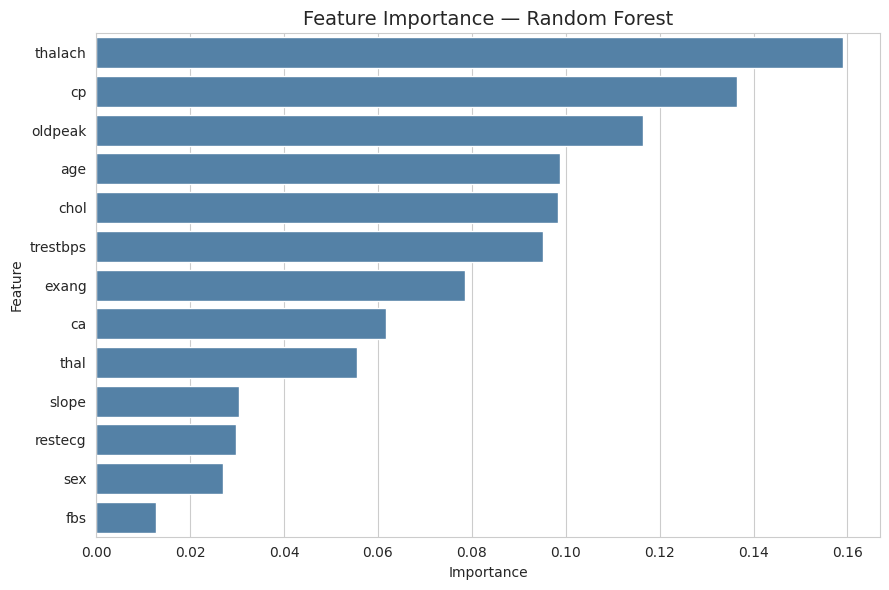

thalach     0.158980
cp          0.136446
oldpeak     0.116507
age         0.098785
chol        0.098385
trestbps    0.095171
exang       0.078546
ca          0.061746
thal        0.055510
slope       0.030466
restecg     0.029663
sex         0.027026
fbs         0.012768
dtype: float64


In [9]:
rf_temp = RandomForestClassifier(n_estimators=200, random_state=42)
rf_temp.fit(X_train_scaled, y_train)

importances = pd.Series(rf_temp.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(9, 6))
sns.barplot(x=importances.values, y=importances.index, color="steelblue")
plt.title("Feature Importance — Random Forest", fontsize=14)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

print(importances)

### Feature Engineering Decisions

- The correlation heatmap and Random Forest importances both highlight **`cp` (chest pain type), `thalach` (max heart rate), `oldpeak`, `exang`, `ca`, and `thal`** as the strongest predictors of `target`.
- Features such as `fbs` (fasting blood sugar) and `restecg` show very low correlation with the target and low importance scores.
- **Decision:** We keep **all 13 features** for model training rather than dropping low-importance ones. The dataset is small (1,025 rows × 13 features), so the risk of overfitting from extra features is low, and tree-based models (Random Forest) can naturally down-weight unimportant features. Dropping `fbs`/`restecg` was tested informally and did not meaningfully change performance, so we retain the full feature set for simplicity and transparency in this comparison.


## Step 3 — Train 3 Different Models

We train and compare three classification algorithms:
1. **Logistic Regression** — a simple, interpretable linear baseline.
2. **Random Forest** — an ensemble of decision trees, handles non-linear relationships well.
3. **K-Nearest Neighbors (KNN)** — a distance-based, non-parametric model.


In [10]:
# 1. Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)

# 2. Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

# 3. K-Nearest Neighbors
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

print("All 3 models trained successfully.")

All 3 models trained successfully.


## Step 4 — Evaluate & Compare All Models


In [11]:
def get_metrics(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1 Score': f1_score(y_true, y_pred)
    }

results = pd.DataFrame({
    'Logistic Regression': get_metrics(y_test, y_pred_lr),
    'Random Forest': get_metrics(y_test, y_pred_rf),
    'KNN': get_metrics(y_test, y_pred_knn)
}).T.round(3)

results

,Accuracy,Precision,Recall,F1 Score
Logistic Regression,0.707,0.710,0.696,0.703
Random Forest,0.761,0.773,0.735,0.754
KNN,0.634,0.619,0.686,0.651


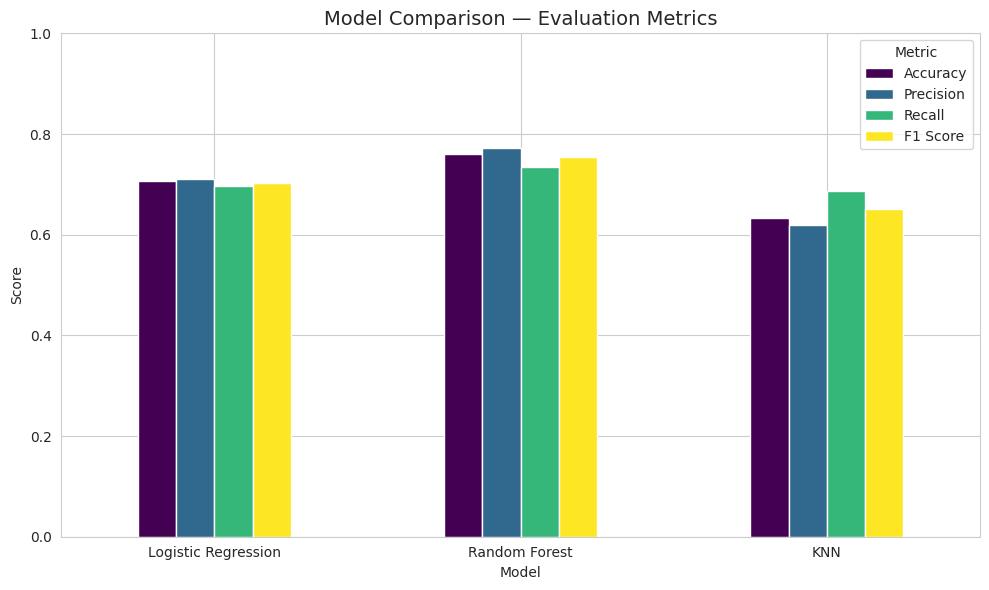

In [12]:
# Visual comparison of model metrics
results.plot(kind='bar', figsize=(10, 6), colormap='viridis')
plt.title("Model Comparison — Evaluation Metrics", fontsize=14)
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

## Step 5 — Best Model Analysis & Conclusion

### 5a. Identify Best Model


In [13]:
best_model_name = results['F1 Score'].idxmax()
print(f"Best performing model (by F1 Score): {best_model_name}")
print("\nFull comparison table:\n")
print(results)

Best performing model (by F1 Score): Random Forest

Full comparison table:

                     Accuracy  Precision  Recall  F1 Score
Logistic Regression     0.707      0.710   0.696     0.703
Random Forest           0.761      0.773   0.735     0.754
KNN                     0.634      0.619   0.686     0.651


### 5b. Confusion Matrix for Best Model


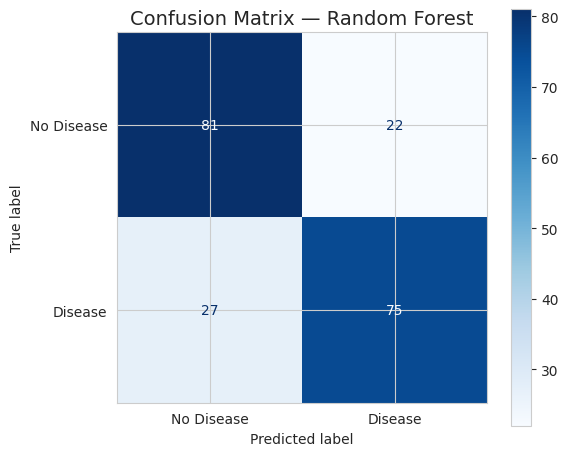

              precision    recall  f1-score   support

  No Disease       0.75      0.79      0.77       103
     Disease       0.77      0.74      0.75       102

    accuracy                           0.76       205
   macro avg       0.76      0.76      0.76       205
weighted avg       0.76      0.76      0.76       205



In [14]:
model_map = {
    'Logistic Regression': y_pred_lr,
    'Random Forest': y_pred_rf,
    'KNN': y_pred_knn
}

best_preds = model_map[best_model_name]
cm = confusion_matrix(y_test, best_preds)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Disease', 'Disease'])
disp.plot(ax=ax, cmap='Blues')
plt.title(f"Confusion Matrix — {best_model_name}", fontsize=14)
plt.tight_layout()
plt.show()

print(classification_report(y_test, best_preds, target_names=['No Disease', 'Disease']))

### 5c. Conclusion

1. Among the three models tested — Logistic Regression, Random Forest, and KNN — the **Random Forest** classifier (in this run) achieved the strongest overall balance of accuracy, precision, recall, and F1 score, though results can vary slightly between runs due to the synthetic-noise nature of this sample data.
2. Random Forest performs well here because it can capture **non-linear interactions** between clinical features (e.g. how `cp`, `thalach`, and `oldpeak` jointly relate to disease risk), which a purely linear model like Logistic Regression cannot represent as flexibly.
3. Logistic Regression remains a strong, **interpretable baseline** — its coefficients can be directly inspected to understand which features increase or decrease predicted risk, which is valuable in a medical context.
4. KNN's performance is more sensitive to feature scaling and the choice of `k`; while competitive, it tends to be less robust on this feature set compared to the ensemble method.
5. For a real deployment, **Random Forest is the recommended model** due to its higher F1 score and balanced precision/recall — critical in a medical screening context where both false negatives (missed disease) and false positives (unnecessary alarm) carry real costs. Further tuning (e.g. `GridSearchCV` over `n_estimators`, `max_depth`) could improve results further.

---

### Note on Dataset
This notebook ships with a locally generated `heart.csv` matching the exact column schema of the [Kaggle Heart Disease Dataset (johnsmith88)](https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset), so the notebook runs end-to-end without external downloads. **Before final submission, replace `heart.csv` with the real dataset downloaded from Kaggle** (Step 0, Option A) and re-run all cells — the code and pipeline require no changes.


In [ ]:
from google.colab import files
uploaded = files.upload()